# Trabalho N2 — Séries Temporais
## Previsão do número mensal de jogos da Seleção Brasileira (1914–2022)

A ordem das etapas acompanha o relatório HTML. A avaliação usa validação walk-forward temporal: cada previsão utiliza apenas dados disponíveis na sua origem.

## Preparação do ambiente

In [13]:
# Se necessário, instale no ambiente do notebook:
# %pip install statsmodels scikit-learn xgboost optuna

import warnings
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import ttest_1samp
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import ParameterSampler
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

# 1. Visão geral da base
Fonte, variável-alvo e granularidade da série.

In [14]:
base_dir = Path.cwd()
caminho = base_dir / 'dados' / 'brazil.csv'
if not caminho.exists():
    candidatos = [base_dir.parent / 'dados' / 'brazil.csv', base_dir.parent.parent / 'dados' / 'brazil.csv']
    caminho = next((p for p in candidatos if p.exists()), caminho)
if not caminho.exists():
    raise FileNotFoundError(f'Não encontrei brazil.csv: {caminho.resolve()}')

df_raw = pd.read_csv(caminho)
df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%d %b %Y', errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
jogos_mes = df.groupby(df['Date'].dt.to_period('M').dt.to_timestamp()).size()
indice_mensal = pd.date_range(jogos_mes.index.min(), jogos_mes.index.max(), freq='MS')
serie = jogos_mes.reindex(indice_mensal, fill_value=0).astype(float).rename('jogos_mes')

print(f'Arquivo: {caminho.resolve()}')
print(f'Partidas: {len(df):,}')
print(f'Período: {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}')
print(f'Meses: {len(serie):,} | sem jogo: {(serie == 0).sum():,}')
print(f'Média: {serie.mean():.3f} | mediana: {serie.median():.1f} | máximo: {serie.max():.0f}')
serie.to_frame().head()

Arquivo: C:\Users\patricksouza-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Germinare TECH\3° Ano\Séries Temporais\ATV - Hot Sarimax Random\GitHub\Modelagem-Comparativa-de-Series-Temporais\brazil\dados\brazil.csv
Partidas: 1,034
Período: 1914-09 a 2022-12
Meses: 1,300 | sem jogo: 859
Média: 0.795 | mediana: 0.0 | máximo: 9


,jogos_mes
1914-09-01,2.0
1914-10-01,0.0
1914-11-01,0.0
1914-12-01,0.0
1915-01-01,0.0


# 2. Variáveis externas
Usamos o ranking FIFA do Brasil e a pontuação relativa ao líder da mesma publicação. Para cada mês-alvo, entram apenas dados publicados antes do início do mês; em previsões de vários passos, o último ranking disponível na origem fica congelado em todo o horizonte. Como o histórico FIFA começa em dezembro de 1992, a comparação dos modelos usa o período comum desde janeiro de 1993.

In [15]:
ranking_path = caminho.parent / 'fifa_ranking-2024-06-20.csv'
if not ranking_path.exists():
    raise FileNotFoundError(f'Não encontrei o histórico do ranking FIFA: {ranking_path.resolve()}')
ranking_raw = pd.read_csv(ranking_path)
ranking_raw['rank_date'] = pd.to_datetime(ranking_raw['rank_date'], errors='raise')
ranking_raw['rank'] = pd.to_numeric(ranking_raw['rank'], errors='coerce')
ranking_raw['total_points'] = pd.to_numeric(ranking_raw['total_points'], errors='coerce')
max_pontos_publicacao = ranking_raw.groupby('rank_date')['total_points'].transform('max')
if max_pontos_publicacao.isna().any() or (max_pontos_publicacao <= 0).any():
    raise ValueError('Há publicação FIFA sem pontuação máxima positiva; não é possível normalizar os pontos.')
ranking_raw['pontos_relativos'] = ranking_raw['total_points'] / max_pontos_publicacao
ranking_brasil = (ranking_raw.loc[ranking_raw['country_abrv'].eq('BRA'),
                                  ['rank_date', 'rank', 'pontos_relativos']]
                  .dropna().sort_values('rank_date').reset_index(drop=True))
if ranking_brasil.empty or ranking_brasil['rank_date'].duplicated().any():
    raise ValueError('O CSV deve conter exatamente um ranking válido do Brasil por publicação.')

def ranking_disponivel(index, as_of=None):
    datas = pd.DatetimeIndex(index)
    consultas = datas if as_of is None else pd.DatetimeIndex([pd.Timestamp(as_of)] * len(datas))
    ordem = np.argsort(consultas.asi8)
    esquerda = pd.DataFrame({'pos': np.arange(len(datas)), 'consulta': consultas}).iloc[ordem]
    associada = pd.merge_asof(
        esquerda, ranking_brasil, left_on='consulta', right_on='rank_date',
        direction='backward', allow_exact_matches=False
    ).sort_values('pos')
    return pd.DataFrame({
        'rank_fifa_brasil': associada['rank'].to_numpy(dtype=float),
        'pontos_fifa_relativos': associada['pontos_relativos'].to_numpy(dtype=float),
    }, index=datas)

def calendario_exog(index, as_of=None):
    index = pd.DatetimeIndex(index)
    mes = index.month.to_numpy()
    calendario = pd.DataFrame({'sin_mes': np.sin(2*np.pi*mes/12), 'cos_mes': np.cos(2*np.pi*mes/12)}, index=index)
    return pd.concat([calendario, ranking_disponivel(index, as_of=as_of)], axis=1)

exog = calendario_exog(serie.index[serie.index >= '1993-01-01'])
matriz_vif = exog.assign(constante=1.0)
vif = pd.DataFrame({'Variável': exog.columns, 'VIF': [variance_inflation_factor(matriz_vif.to_numpy(), i) for i in range(exog.shape[1])]})
dicionario_exog = pd.DataFrame([
    {'Variável':'sin_mes', 'Descrição':'Componente seno do mês do calendário', 'Disponível na origem':'sim; determinística'},
    {'Variável':'cos_mes', 'Descrição':'Componente cosseno do mês do calendário', 'Disponível na origem':'sim; determinística'},
    {'Variável':'rank_fifa_brasil', 'Descrição':'Posição do Brasil no ranking FIFA (1 = melhor)', 'Disponível na origem':'sim; última publicação anterior à previsão'},
    {'Variável':'pontos_fifa_relativos', 'Descrição':'Pontos do Brasil divididos pelos pontos do líder na mesma publicação', 'Disponível na origem':'sim; última publicação anterior à previsão'},
])
print(f'Fonte: {ranking_path.name} | {len(ranking_brasil)} publicações do Brasil; {ranking_brasil.rank_date.min():%Y-%m-%d} a {ranking_brasil.rank_date.max():%Y-%m-%d}')
display(dicionario_exog)
display(vif.round(3))

Fonte: fifa_ranking-2024-06-20.csv | 333 publicações do Brasil; 1992-12-31 a 2024-06-20


,Variável,Descrição,Disponível na origem
0,sin_mes,Componente seno do mês do calendário,sim; determinística
1,cos_mes,Componente cosseno do mês do calendário,sim; determinística
2,rank_fifa_brasil,Posição do Brasil no ranking FIFA (1 = melhor),sim; última publicação anterior à previsão
3,pontos_fifa_relativos,Pontos do Brasil divididos pelos pontos do líd...,sim; última publicação anterior à previsão


,Variável,VIF
0,sin_mes,1.003
1,cos_mes,1.000
2,rank_fifa_brasil,4.394
3,pontos_fifa_relativos,4.392


# 3. Limpeza e exploração
Datas repetidas podem representar jogos diferentes no mesmo dia e são mantidas. Placar e competição não definem a variável-alvo, que é a contagem de partidas por mês.

Valores ausentes por coluna:


,ausentes
Date,0
Match,0
Result,0
Score,1
Competition,1


Linhas duplicadas: 0
Datas repetidas (mantidas): 3
Datas inválidas descartadas: 0
Placares fora do padrão N-N: 16 (não usados na série-alvo)


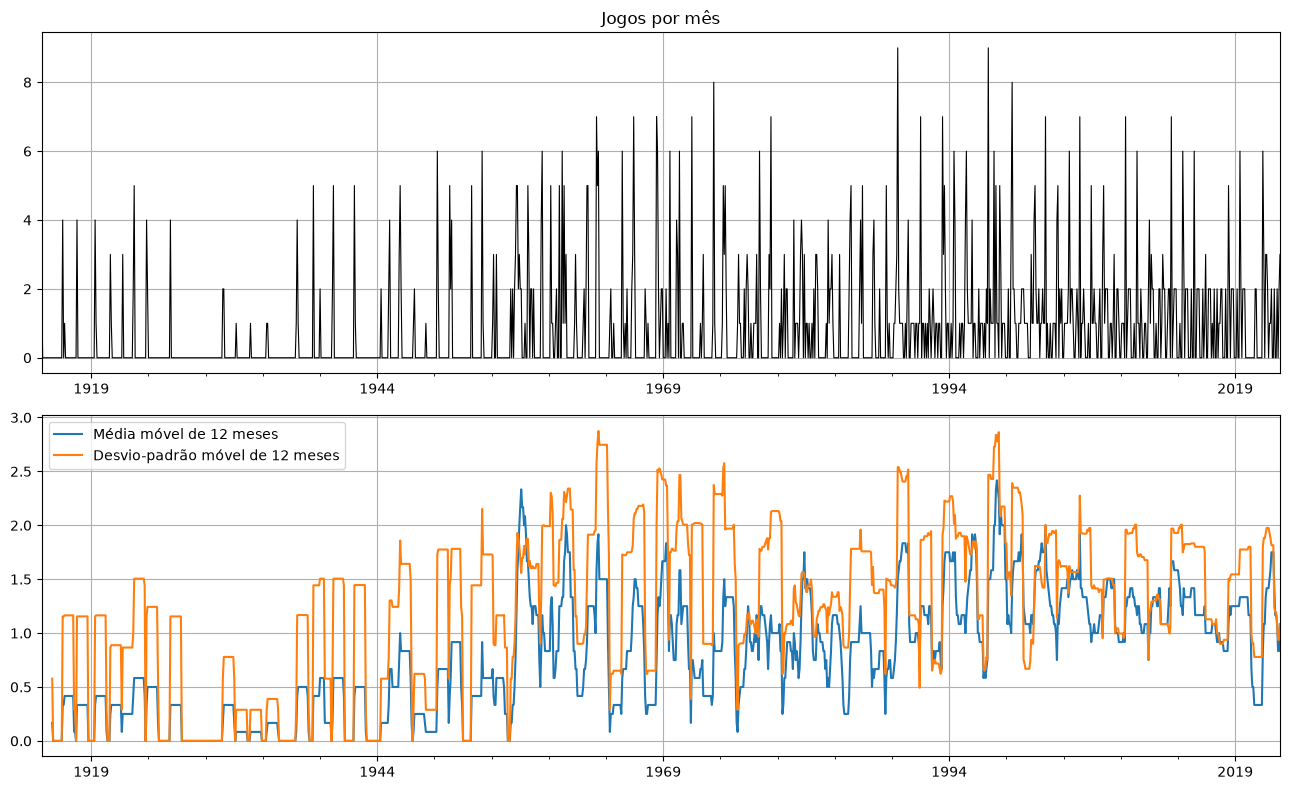

,mean,median,std
mês,,,
1,0.31,0.0,0.96
2,0.42,0.0,0.89
3,0.94,0.0,1.53
4,0.69,0.0,1.30
5,0.81,0.0,1.38
6,2.39,2.0,2.61
7,1.25,0.0,2.06
8,0.51,0.0,1.02
9,0.68,0.0,0.91


In [16]:
print('Valores ausentes por coluna:')
display(df_raw.isna().sum().rename('ausentes').to_frame())
datas = pd.to_datetime(df_raw['Date'], format='%d %b %Y', errors='coerce')
print(f'Linhas duplicadas: {df_raw.duplicated().sum()}')
print(f'Datas repetidas (mantidas): {datas.duplicated().sum()}')
print(f'Datas inválidas descartadas: {datas.isna().sum()}')
fora_padrao = (~df_raw['Score'].dropna().str.match(r'^\d+-\d+$')).sum()
print(f'Placares fora do padrão N-N: {fora_padrao} (não usados na série-alvo)')

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
serie.plot(ax=axes[0], color='black', linewidth=0.8, title='Jogos por mês')
serie.rolling(12).mean().plot(ax=axes[1], label='Média móvel de 12 meses')
serie.rolling(12).std().plot(ax=axes[1], label='Desvio-padrão móvel de 12 meses')
axes[1].legend()
plt.tight_layout()
plt.show()
resumo_mes = serie.groupby(serie.index.month).agg(['mean','median','std']).round(2)
resumo_mes.index.name = 'mês'
display(resumo_mes)

# 4. Decomposição STL
Examinamos sazonalidade anual (12 meses). ADF e KPSS são diagnósticos; o SARIMA emprega diferença sazonal D=1 na etapa de modelagem.

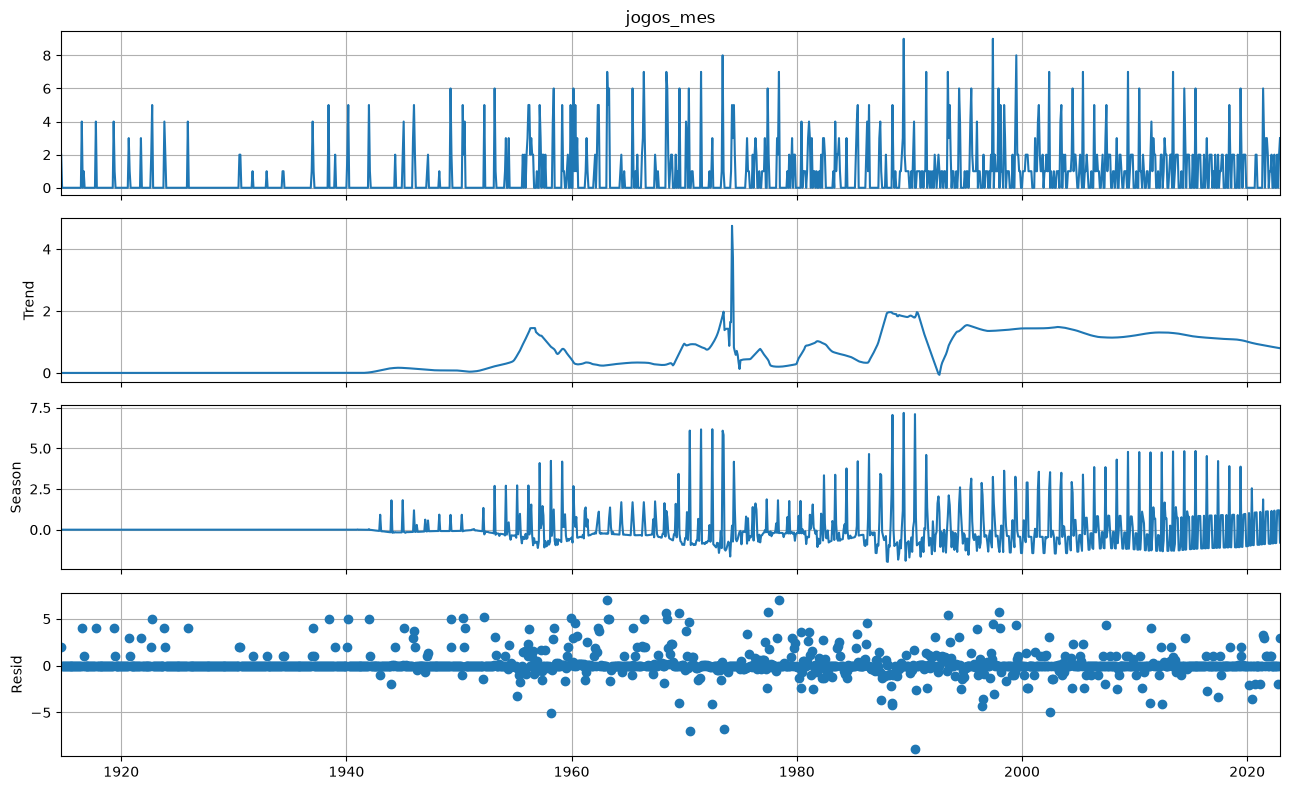

Força da sazonalidade: 0.2549
Força da tendência: 0.0745


,efeito sazonal
1,-0.55
2,-0.37
3,0.23
4,-0.26
5,-0.20
6,1.48
7,0.69
8,-0.23
9,-0.02
10,-0.11


ADF p-valor: 0.0043 | KPSS p-valor: 0.0100


C:\Users\patricksouza-ieg\AppData\Local\Temp\ipykernel_11948\2002958675.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(serie, autolag='AIC')[1]
C:\Users\patricksouza-ieg\AppData\Local\Temp\ipykernel_11948\2002958675.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(serie, regression='c', nlags='auto')[1]
C:\Users\patricksouza-ieg\AppData\Local\Temp\ipykernel_11948\2002958675.py:13: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` w

In [17]:
resultado_stl = STL(serie, period=12, robust=True).fit()
fig = resultado_stl.plot()
fig.set_size_inches(13, 8)
plt.tight_layout()
plt.show()
tendencia, sazonal, residuo_stl = resultado_stl.trend, resultado_stl.seasonal, resultado_stl.resid
forca_sazonalidade = max(0, 1 - np.var(residuo_stl)/np.var(sazonal + residuo_stl))
forca_tendencia = max(0, 1 - np.var(residuo_stl)/np.var(tendencia + residuo_stl))
print(f'Força da sazonalidade: {forca_sazonalidade:.4f}')
print(f'Força da tendência: {forca_tendencia:.4f}')
display(sazonal.groupby(sazonal.index.month).mean().rename('efeito sazonal').round(2).to_frame())
adf_p = adfuller(serie, autolag='AIC')[1]
kpss_p = kpss(serie, regression='c', nlags='auto')[1]
print(f'ADF p-valor: {adf_p:.4f} | KPSS p-valor: {kpss_p:.4f}')

# 5. Feature engineering
As mesmas 30 features alimentam Random Forest e XGBoost: 12 lags, 4 médias móveis, 3 desvios-padrão móveis e 11 indicadores de mês (janeiro é a referência). Todas as janelas terminam antes do mês-alvo.

In [18]:
serie_completa = serie.copy()
serie = serie.loc['1993-01-01':].copy()
assert serie.index.min() == pd.Timestamp('1993-01-01') and ranking_disponivel(serie.index).notna().all().all()
print(f'Período comum para modelagem: {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m} ({len(serie)} meses).')

FEATURES = ([f'jogos_lag_{k}' for k in range(1,13)] + [f'media_{k}' for k in (3,6,9,12)] + [f'dp_{k}' for k in (3,6,12)] + [f'mes_{k}' for k in range(2,13)] + ['rank_fifa_brasil','pontos_fifa_relativos'])

def vetor_features(historico, data_alvo, data_corte_exog=None):
    valores = historico.to_numpy(dtype=float)
    if len(valores) < 12:
        raise ValueError('São necessários ao menos 12 meses de histórico.')
    linha = {f'jogos_lag_{k}': valores[-k] for k in range(1,13)}
    for k in (3,6,9,12): linha[f'media_{k}'] = valores[-k:].mean()
    for k in (3,6,12): linha[f'dp_{k}'] = valores[-k:].std(ddof=0)
    for k in range(2,13): linha[f'mes_{k}'] = int(data_alvo.month == k)
    exog_alvo = calendario_exog(pd.DatetimeIndex([data_alvo]), as_of=data_corte_exog).iloc[0]
    linha['rank_fifa_brasil'] = exog_alvo['rank_fifa_brasil']
    linha['pontos_fifa_relativos'] = exog_alvo['pontos_fifa_relativos']
    return pd.Series(linha, index=FEATURES, dtype=float)

def montar_supervisionado(y):
    linhas, alvos, datas = [], [], []
    valores = y.astype(float)
    for pos in range(12, len(valores)):
        data_alvo = valores.index[pos]
        linhas.append(vetor_features(valores.iloc[:pos], data_alvo))
        alvos.append(float(valores.iloc[pos]))
        datas.append(data_alvo)
    X = pd.DataFrame(linhas, index=pd.DatetimeIndex(datas), columns=FEATURES)
    return X, pd.Series(alvos, index=X.index, name=y.name)

X_tudo, y_tudo = montar_supervisionado(serie)
assert X_tudo.shape[1] == 32 and X_tudo.index.min() > serie.index.min()
assert np.isfinite(X_tudo.to_numpy()).all()
print(f'Matriz: {X_tudo.shape[0]} observações × {X_tudo.shape[1]} features')
print('Teste anti-vazamento passou: lags/janelas usam apenas passado e o ranking é limitado à informação disponível na origem.')
display(pd.DataFrame({'família':['lags','médias móveis','desvios móveis','calendário','ranking FIFA'], 'n_features':[12,4,3,11,2]}))

Período comum para modelagem: 1993-01 a 2022-12 (360 meses).
Matriz: 348 observações × 32 features
Teste anti-vazamento passou: lags/janelas usam apenas passado e o ranking é limitado à informação disponível na origem.


,família,n_features
0,lags,12
1,médias móveis,4
2,desvios móveis,3
3,calendário,11
4,ranking FIFA,2


# 6. Protocolo walk-forward
O ajuste usa validação interna anterior ao teste. A avaliação final contém 15 origens mensais consecutivas; em cada uma, reajustamos os modelos com o histórico disponível e prevemos os 4 meses seguintes. São 60 previsões por modelo, com horizontes sobrepostos.

In [19]:
MESES_SAZONAIS, HORIZONTE = 12, 4
CORTE_TUNING = pd.Timestamp('2019-12-01')
ORIGENS_VALIDACAO = [pd.Timestamp('2020-01-01'), pd.Timestamp('2020-05-01')]
ORIGENS_TESTE = pd.date_range('2021-06-01', '2022-08-01', freq='MS')
assert len(ORIGENS_TESTE) == 15
assert ORIGENS_TESTE[-1] + pd.offsets.MonthBegin(HORIZONTE) <= serie.index[-1]
print(f'Tuning: treino até {CORTE_TUNING:%Y-%m}; {len(ORIGENS_VALIDACAO)} origens × {HORIZONTE} passos.')
print(f'Teste: {len(ORIGENS_TESTE)} origens ({ORIGENS_TESTE[0]:%Y-%m} a {ORIGENS_TESTE[-1]:%Y-%m}) × {HORIZONTE} = {len(ORIGENS_TESTE)*HORIZONTE} previsões por modelo.')

Tuning: treino até 2019-12; 2 origens × 4 passos.
Teste: 15 origens (2021-06 a 2022-08) × 4 = 60 previsões por modelo.


# 7. Modelos e hiperparâmetros
Comparamos SARIMAX sazonal com calendário determinístico, Holt-Winters, Random Forest e XGBoost. A seleção ocorre apenas na validação interna: grade BIC + MAE temporal para SARIMAX, 40 amostras para Random Forest e 60 trials Optuna/TPE para XGBoost.

In [ ]:
def datas_futuras(origem, passos=HORIZONTE):
    return pd.date_range(origem + pd.offsets.MonthBegin(1), periods=passos, freq='MS')

def prever_sarimax(hist, ordem, sazonal, passos=HORIZONTE):
    datas = datas_futuras(hist.index[-1], passos)
    exog_treino = calendario_exog(hist.index)
    exog_futuro = calendario_exog(datas, as_of=datas[0])
    modelo = SARIMAX(hist, exog=exog_treino, order=ordem, seasonal_order=sazonal,
                     trend='c', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=150)
    pred = modelo.get_forecast(steps=passos, exog=exog_futuro).predicted_mean.clip(lower=0)
    return pred, modelo

def mae_cv_sarimax(ordem, sazonal):
    erros=[]
    for origem in ORIGENS_VALIDACAO:
        hist=serie.loc[:origem]; pred,_=prever_sarimax(hist,ordem,sazonal)
        erros.extend((serie.reindex(pred.index)-pred).abs().tolist())
    return float(np.mean(erros))

candidatos=[]; treino_tuning=serie.loc[:CORTE_TUNING]
for p,q,P,Q in product(range(3),range(3),range(3),range(3)):
    ordem_cand=(p,0,q); sazonal_cand=(P,1,Q,MESES_SAZONAIS)
    fit=SARIMAX(treino_tuning, exog=calendario_exog(treino_tuning.index), order=ordem_cand,
                seasonal_order=sazonal_cand, trend='c', enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False,maxiter=150)
    candidatos.append({'ordem':ordem_cand,'sazonal':sazonal_cand,'AIC':fit.aic,'BIC':fit.bic})
grade_sarimax=pd.DataFrame(candidatos).sort_values('BIC').reset_index(drop=True)
selecao_sarimax=[]
for _,row in grade_sarimax.head(5).iterrows():
    selecao_sarimax.append({**row.to_dict(),'MAE validação':mae_cv_sarimax(row['ordem'],row['sazonal'])})
selecao_sarimax=pd.DataFrame(selecao_sarimax).sort_values('MAE validação').reset_index(drop=True)
ordem_sarimax=selecao_sarimax.loc[0,'ordem']; ordem_sazonal_sarimax=selecao_sarimax.loc[0,'sazonal']

configs_hw=[]
for trend in (None,'add'):
    for damped in ((False,) if trend is None else (False,True)):
        for seasonal in (None,'add'):
            for init in ('estimated','heuristic'):
                configs_hw.append({'trend':trend,'damped_trend':damped,'seasonal':seasonal,
                                   'seasonal_periods':12 if seasonal else None,'initialization_method':init})
def prever_hw(hist,config,passos=HORIZONTE):
    fit=ExponentialSmoothing(hist,trend=config['trend'],damped_trend=config['damped_trend'],
        seasonal=config['seasonal'],seasonal_periods=config['seasonal_periods'],
        initialization_method=config['initialization_method']).fit(optimized=True,use_brute=False)
    pred=fit.forecast(passos); pred.index=datas_futuras(hist.index[-1],passos)
    return pred.clip(lower=0)
def mae_cv_hw(config):
    erros=[]
    for origem in ORIGENS_VALIDACAO:
        hist=serie.loc[:origem]; pred=prever_hw(hist,config)
        erros.extend((serie.reindex(pred.index)-pred).abs().tolist())
    return float(np.mean(erros))
resultados_hw=[{'config':c,'MAE validação':mae_cv_hw(c)} for c in configs_hw]
selecao_hw=min(resultados_hw,key=lambda x:x['MAE validação']); config_hw_final=selecao_hw['config']

def features_supervisionadas(hist): return montar_supervisionado(hist)
def prever_arvore(hist,modelo,passos=HORIZONTE):
    X,y=features_supervisionadas(hist); modelo.fit(X,y); rec=hist.copy(); datas=datas_futuras(rec.index[-1],passos); preds=[]
    for data in datas:
        valor=max(0.0,float(modelo.predict(vetor_features(rec,data,data_corte_exog=datas[0]).to_frame().T)[0]))
        preds.append(valor); rec.loc[data]=valor
    return pd.Series(preds,index=datas,dtype=float)
def mae_cv_arvore(fabrica):
    erros=[]
    for origem in ORIGENS_VALIDACAO:
        hist=serie.loc[:origem]; pred=prever_arvore(hist,fabrica())
        erros.extend((serie.reindex(pred.index)-pred).abs().tolist())
    return float(np.mean(erros))

rf_space={'n_estimators':[200,500],'max_depth':[None,6,12,20],
          'min_samples_split':[2,5,10],'min_samples_leaf':[1,3,5],'max_features':['sqrt',0.5,1.0]}
configs_rf=list(ParameterSampler(rf_space,n_iter=40,random_state=42)); resultados_rf=[]
for params in configs_rf:
    score=mae_cv_arvore(lambda params=params: RandomForestRegressor(**params,random_state=42,n_jobs=-1))
    resultados_rf.append({'params':params,'MAE validação':score})
config_rf_final=min(resultados_rf,key=lambda x:x['MAE validação'])['params']

def xgb_params(trial):
    return {'n_estimators':trial.suggest_int('n_estimators',100,500,step=50),
      'max_depth':trial.suggest_int('max_depth',2,8),'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
      'min_child_weight':trial.suggest_int('min_child_weight',1,20),'subsample':trial.suggest_float('subsample',0.5,1.0),
      'colsample_bytree':trial.suggest_float('colsample_bytree',0.4,1.0),'gamma':trial.suggest_float('gamma',0.0,5.0),
      'reg_alpha':trial.suggest_float('reg_alpha',1e-3,10.0,log=True),'reg_lambda':trial.suggest_float('reg_lambda',1e-3,10.0,log=True),
      'objective':trial.suggest_categorical('objective',['reg:squarederror','reg:absoluteerror'])}
def criar_xgb(params): return XGBRegressor(**params,random_state=42,n_jobs=1,tree_method='hist',verbosity=0)
estudo=optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=42))
estudo.optimize(lambda trial: mae_cv_arvore(lambda:criar_xgb(xgb_params(trial))),n_trials=60,show_progress_bar=False)
config_xgb_final=estudo.best_params

print(f'SARIMAX{ordem_sarimax} × {ordem_sazonal_sarimax}; MAE validação={selecao_sarimax.loc[0,"MAE validação"]:.3f}')
print(f'Holt-Winters: {config_hw_final}; MAE validação={selecao_hw["MAE validação"]:.3f}')
print(f'Random Forest: {config_rf_final}; MAE validação={min(r["MAE validação"] for r in resultados_rf):.3f} (40 combinações)')
print(f'XGBoost: {config_xgb_final}; MAE validação={estudo.best_value:.3f} (60 trials TPE)')

# 8. Resultados comparativos (MAE)
O MAE é calculado sobre as mesmas 60 previsões por modelo. Também mostramos o erro por passo do horizonte. Os resultados são recalculados pelo walk-forward, sem reutilizar métricas antigas do HTML.

In [9]:
def prever_media(hist,passos=HORIZONTE): return pd.Series([hist.mean()]*passos,index=datas_futuras(hist.index[-1],passos))
def prever_sazonal_ingenua(hist,passos=HORIZONTE):
    datas=datas_futuras(hist.index[-1],passos)
    return pd.Series([hist.iloc[-12+(i%12)] for i in range(passos)],index=datas)

def prever_rf(hist,passos=HORIZONTE): return prever_arvore(hist,RandomForestRegressor(**config_rf_final,random_state=42,n_jobs=-1),passos)
def prever_xgb(hist,passos=HORIZONTE): return prever_arvore(hist,criar_xgb(config_xgb_final),passos)
MODELOS={'Média histórica':prever_media,'Sazonal ingênuo (12)':prever_sazonal_ingenua,
         'SARIMAX':lambda h:prever_sarimax(h,ordem_sarimax,ordem_sazonal_sarimax)[0],
         'Holt-Winters':lambda h:prever_hw(h,config_hw_final),'Random Forest':prever_rf,'XGBoost':prever_xgb}
linhas=[]; modelo_sarimax_ultimo=None
for origem in ORIGENS_TESTE:
    hist=serie.loc[:origem]; datas=datas_futuras(origem); real=serie.reindex(datas)
    for nome,funcao in MODELOS.items():
        if nome=='SARIMAX': pred,modelo_sarimax_ultimo=prever_sarimax(hist,ordem_sarimax,ordem_sazonal_sarimax)
        else: pred=funcao(hist)
        if pred.isna().any() or real.isna().any() or not np.isfinite(pred.to_numpy()).all():
            raise ValueError(f'Previsão/real inválido: {nome}, origem {origem:%Y-%m}')
        for passo,data in enumerate(datas,start=1):
            linhas.append({'Modelo':nome,'Origem':origem,'Data':data,'Horizonte':passo,
                           'Real':float(real.loc[data]),'Previsto':float(pred.loc[data]),
                           'Erro abs.':abs(float(real.loc[data])-float(pred.loc[data]))})
previsoes_walkforward=pd.DataFrame(linhas)
assert len(previsoes_walkforward)==len(MODELOS)*60
metricas_walkforward=(previsoes_walkforward.groupby('Modelo')['Erro abs.'].agg(MAE='mean',N='count').sort_values('MAE').reset_index())
mae_por_horizonte=previsoes_walkforward.pivot_table(index='Modelo',columns='Horizonte',values='Erro abs.',aggfunc='mean')
print('MAE global:'); display(metricas_walkforward.round(3))
print('MAE por horizonte:'); display(mae_por_horizonte.round(3))

MAE global:


,Modelo,MAE,N
0,SARIMAX,0.801,60
1,XGBoost,0.967,60
2,Random Forest,0.978,60
3,Holt-Winters,1.050,60
4,Média histórica,1.052,60
5,Sazonal ingênuo (12),1.267,60


MAE por horizonte:


Horizonte,1,2,3,4
Modelo,,,,
Holt-Winters,1.107,1.013,1.040,1.040
Média histórica,1.109,1.014,1.042,1.042
Random Forest,0.958,1.026,0.990,0.938
SARIMAX,0.750,0.800,0.773,0.883
Sazonal ingênuo (12),1.267,1.267,1.267,1.267
XGBoost,0.970,0.944,0.929,1.024


# 9. Resíduos e Ljung-Box
Para não tratar previsões sobrepostas de vários passos como resíduos independentes, os testes usam somente erros de horizonte 1 nas 15 origens.

Modelo líder: SARIMAX; resíduos h=1: 15


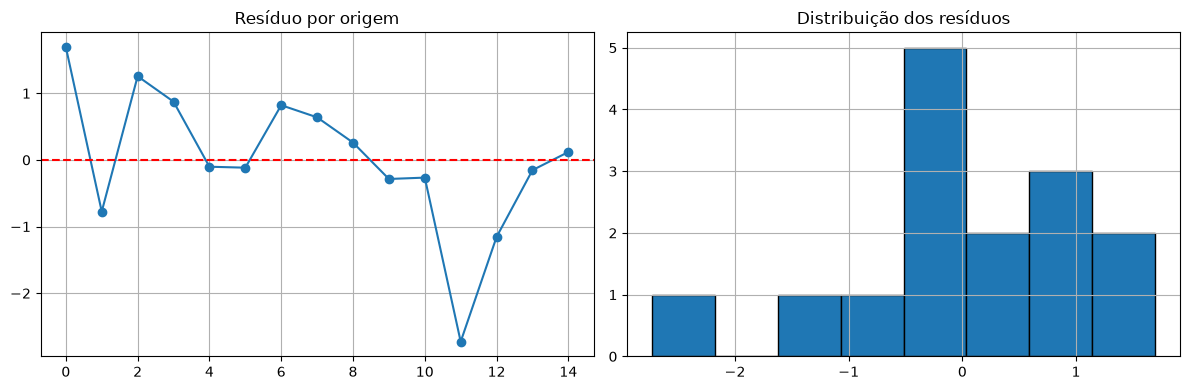

,lb_stat,lb_pvalue,Conclusão (5%)
1,0.8148,0.3667,sem evidência de autocorrelação
3,1.3362,0.7206,sem evidência de autocorrelação
6,2.1833,0.9021,sem evidência de autocorrelação


Resíduo médio: 0.006 | t-test p-valor: 0.9842


In [10]:
melhor_modelo=metricas_walkforward.loc[0,'Modelo']
residuos_h1=(previsoes_walkforward.query('Modelo == @melhor_modelo and Horizonte == 1')
             .assign(Residuo=lambda x:x['Real']-x['Previsto']).sort_values('Data')['Residuo'])
print(f'Modelo líder: {melhor_modelo}; resíduos h=1: {len(residuos_h1)}')
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(residuos_h1.to_numpy(),marker='o'); axes[0].axhline(0,color='red',linestyle='--'); axes[0].set_title('Resíduo por origem')
axes[1].hist(residuos_h1,bins=8,edgecolor='black'); axes[1].set_title('Distribuição dos resíduos')
plt.tight_layout(); plt.show()
lags=[lag for lag in (1,3,6) if lag<len(residuos_h1)]
ljung_box=acorr_ljungbox(residuos_h1,lags=lags,return_df=True)
ljung_box['Conclusão (5%)']=np.where(ljung_box['lb_pvalue']>0.05,'sem evidência de autocorrelação','autocorrelação restante')
display(ljung_box.round(4))
teste_vies=ttest_1samp(residuos_h1,popmean=0)
print(f'Resíduo médio: {residuos_h1.mean():.3f} | t-test p-valor: {teste_vies.pvalue:.4f}')

# 10. Importância das features
Importância por permutação é calculada em uma janela temporal interna independente do teste final (outubro de 2020 a maio de 2021, previsão de um passo). O resumo por família agrupa lags, janelas móveis e calendário.

In [11]:
CORTE_IMP=pd.Timestamp('2020-09-01'); FIM_IMP=pd.Timestamp('2021-05-01')
X_imp_treino,y_imp_treino=montar_supervisionado(serie.loc[:CORTE_IMP])
X_base,y_base=montar_supervisionado(serie)
mask=(X_base.index>CORTE_IMP)&(X_base.index<=FIM_IMP)
X_imp_valid=X_base.loc[mask]; y_imp_valid=y_base.reindex(X_imp_valid.index)
modelo_importancia=criar_xgb(config_xgb_final).fit(X_imp_treino,y_imp_treino)
imp=permutation_importance(modelo_importancia,X_imp_valid,y_imp_valid,scoring='neg_mean_absolute_error',n_repeats=5,random_state=42,n_jobs=1)
tabela_importancia=pd.DataFrame({'Feature':FEATURES,'Importância':imp.importances_mean}).sort_values('Importância',ascending=False)
display(tabela_importancia.head(10).round(4))
def familia_feature(nome):
    if nome.startswith('jogos_lag_'): return 'lags'
    if nome.startswith('media_') or nome.startswith('dp_'): return 'janelas móveis'
    if nome in ('rank_fifa_brasil','pontos_fifa_relativos'): return 'ranking FIFA'
    return 'calendário mensal'
tabela_familias=(tabela_importancia.assign(Família=lambda x:x['Feature'].map(familia_feature)).groupby('Família',as_index=False)['Importância'].sum().sort_values('Importância',ascending=False))
display(tabela_familias.round(4))
coef=modelo_sarimax_ultimo.params
coef_nomes=[n for n in coef.index if n in ('sin_mes','cos_mes','rank_fifa_brasil','pontos_fifa_relativos')]
tabela_coef=pd.DataFrame({'Variável':coef_nomes,'Coeficiente':[coef[n] for n in coef_nomes]})
display(tabela_coef.round(4))

,Feature,Importância
11,jogos_lag_12,0.1333
0,jogos_lag_1,0.0322
16,dp_3,0.0230
12,media_3,0.0150
10,jogos_lag_11,0.0103
29,mes_12,0.0065
2,jogos_lag_3,0.0063
17,dp_6,0.0063
5,jogos_lag_6,0.0026
1,jogos_lag_2,0.0009


,Família,Importância
2,lags,0.1794
1,janelas móveis,0.0442
0,calendário mensal,0.0023


,Variável,Coeficiente
0,sin_mes,0.0
1,cos_mes,-0.0


# 11. Conclusão
A conclusão é produzida a partir das métricas do walk-forward. Diferenças pequenas devem ser interpretadas com cautela: as janelas de previsão se sobrepõem e a série tem muitos meses sem partidas.

In [12]:
melhor=metricas_walkforward.iloc[0]; segundo=metricas_walkforward.iloc[1]
melhora=(segundo['MAE']-melhor['MAE'])/segundo['MAE']*100 if segundo['MAE'] else 0
print(f'Melhor modelo: {melhor["Modelo"]} (MAE={melhor["MAE"]:.3f}, n={int(melhor["N"])}).')
print(f'Segundo colocado: {segundo["Modelo"]} (MAE={segundo["MAE"]:.3f}); diferença relativa={melhora:.1f}%.')
print(f'Série exploratória completa: {serie_completa.index.min():%Y-%m}–{serie_completa.index.max():%Y-%m}. Comparação com exógenas: {serie.index.min():%Y-%m}–{serie.index.max():%Y-%m}; {(serie==0).sum()} de {len(serie)} meses sem jogos.')
print('Exógenas: posição e pontos relativos do ranking FIFA, usando somente a publicação conhecida na origem; no horizonte futuro, o valor é congelado para evitar antecipação.')
print('Todos os modelos foram avaliados nas mesmas 15 origens e 4 horizontes; hiperparâmetros foram selecionados antes do teste final.')

Melhor modelo: SARIMAX (MAE=0.801, n=60).
Segundo colocado: XGBoost (MAE=0.967); diferença relativa=17.1%.
Série: jogos_mes, mensal, 1914-09–2022-12; 859 de 1300 meses sem jogos.
Limitação: a base não contém calendário futuro de torneios; variáveis derivadas de jogos realizados foram excluídas para evitar vazamento.
Todos os modelos foram avaliados nas mesmas 15 origens e 4 horizontes; hiperparâmetros foram selecionados antes do teste final.
